## Seasonal Agriculture Performance Analysis
### Major Data Analytics Project
**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance 

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn
### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.


## 1.Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changesacross seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differencesin agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data. 

## 2.Project Outcome
* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Use appropriate univariate, bivariate and multivariate visualizations.
* Identify significant findings from the data.


## 3. Dataset
The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** seasonal_agriculture_performance_dataset.csv

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme (style="whitegrid")
pd.set_option("display.max_columns" ,None)
pd.set_option ("display.float_format", lambda x: f"{x:,.2f}")

In [170]:
df=pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


## 4.Initial Data Understanding

In [171]:
print("Number of Rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of Rows: 4000
Number of columns: 28


In [172]:
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [173]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [174]:
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [175]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [177]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [178]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis
Before performing analysis, investigate missing values, duplicates, data types and unusual values.



In [179]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})
missing_summary[missing_summary["Missing_Count"]>0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


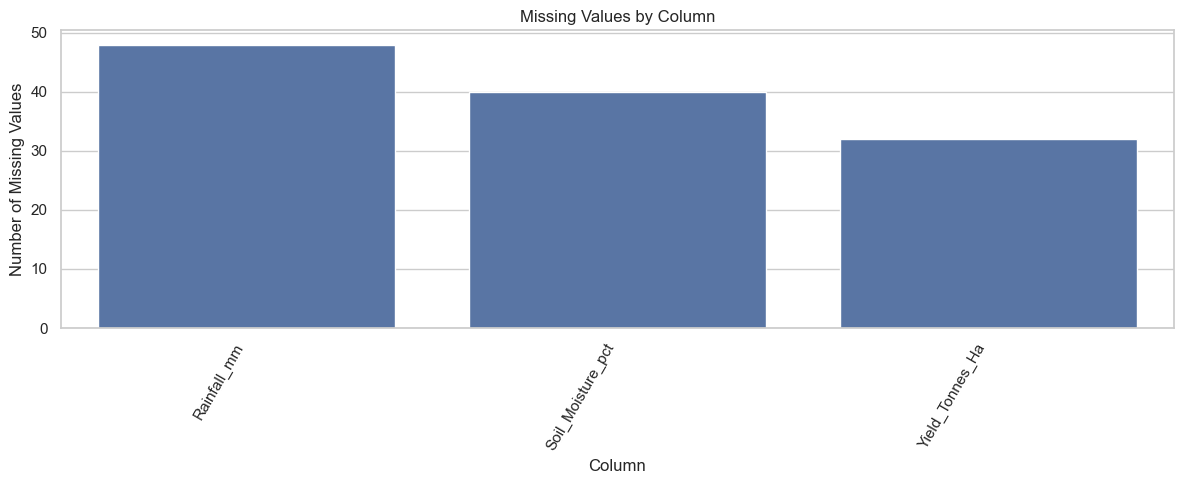

In [180]:
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len (missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot. values)
    plt.xticks(rotation=60, ha="right") 
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title( "Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print ("No missing values found.")

In [181]:
duplicate_count = df. duplicated(). sum()
print ("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [182]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [183]:
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [184]:
#Check unique values for categorical columns
categorical_columns = df.select_dtypes (include="object").columns
for col in categorical_columns:
    print (f"\n{col}: ")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna(). unique()[:20])


Farm_ID: 
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State: 
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District: 
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop: 
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season: 
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method: 
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [185]:
df.isnull().sum().sort_values(ascending=False).head(10)

Rainfall_mm           48
Soil_Moisture_pct     40
Yield_Tonnes_Ha       32
Farm_ID                0
Crop                   0
District               0
Farm_Area_Hectares     0
Season                 0
Avg_Temperature_C      0
Humidity_pct           0
dtype: int64

## Missing Value Treatment
Choose an appropriate strategy based on the nature of each variable.
### Possible approaches:
* Remove records only when justified.
* Fill numerical values using an appropriate statistic when appropriate.
* Fill categorical values using a suitable category or method.
* Clearly document why the chosen approach is reasonable.


In [186]:
# Example: median imputation for numerical columns
# Students should review missingness before deciding whether to use this approach.

numeric_columns=df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
print ("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 6. Feature / Variable Review
Review the available variables and classify them conceptually as:
* Identifier variables
* Categorical variables
* Numerical variables
* Environmental variables
* Operational variables
* Production/performance variables
* Economic variables

In [187]:
# Numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object"). columns. tolist()
print( "Numerical columns:")
print (numeric_columns)
print(" \nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
 
Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 7. Statistical Analysis
Perform descriptive statistical analysis to understand the distribution and variation of the data.

Students should interpret the statistics rather than simply displaying them.

In [188]:
# Descriptive statistics
stats=df[numeric_columns].describe().T
stats["range"] = stats["max"]-stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [189]:
# Median and standard deviation
statistical_summary = pd.DataFrame({
"Mean": df[numeric_columns].mean(),
"Median":df[numeric_columns].median(),
"Std Dev":df[numeric_columns].std(),
"Min": df[numeric_columns].min(),
"Max": df[numeric_columns].max()
})
statistical_summary

,Mean,Median,Std Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [190]:
#Seasonal descriptive summary
season_summary = df .groupby( "Season") [numeric_columns] .agg( ["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 8. Univariate Analysis
Univariase analysis examines one variable at a time

Create and interpret suitable plots for:
* Important categorical varisbles
* Important numorical variabics
* Seasonal distribution
* Production performance distributices
* Economic distributions
  
The examples below are stating points. Students should add or modify plots based on their own analytical question

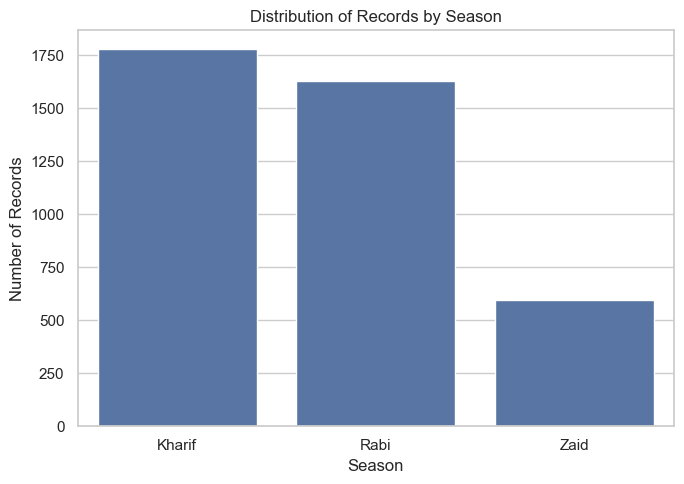

In [192]:
#Univariate: Season distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season") 
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

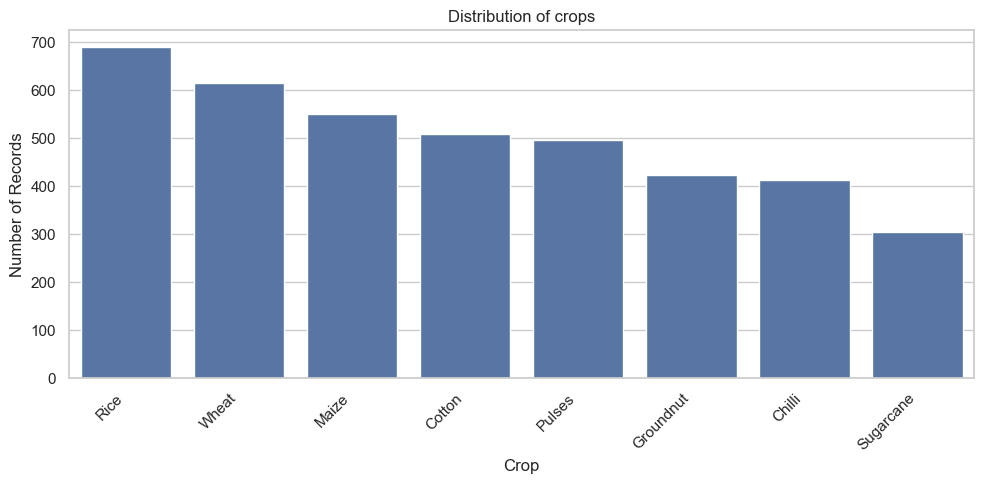

In [193]:
#Univariate: Crop distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title( "Distribution of crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

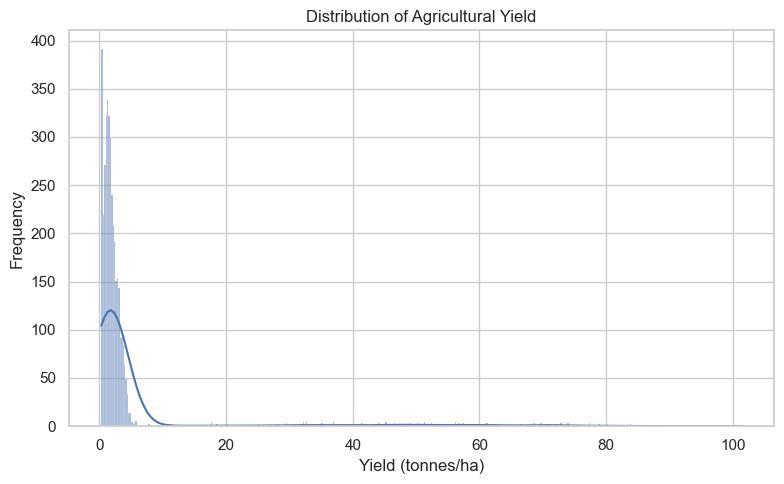

In [194]:
#Univariate: Yield distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield") 
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt. show()

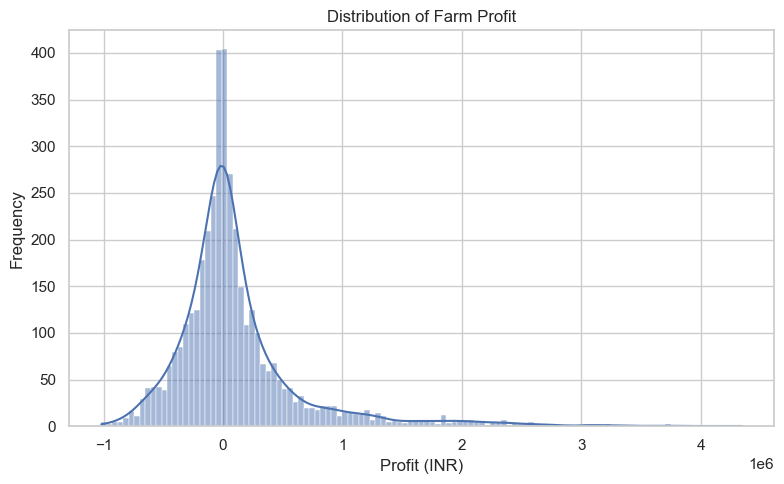

In [195]:
#Univariate: Profit distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title( "Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

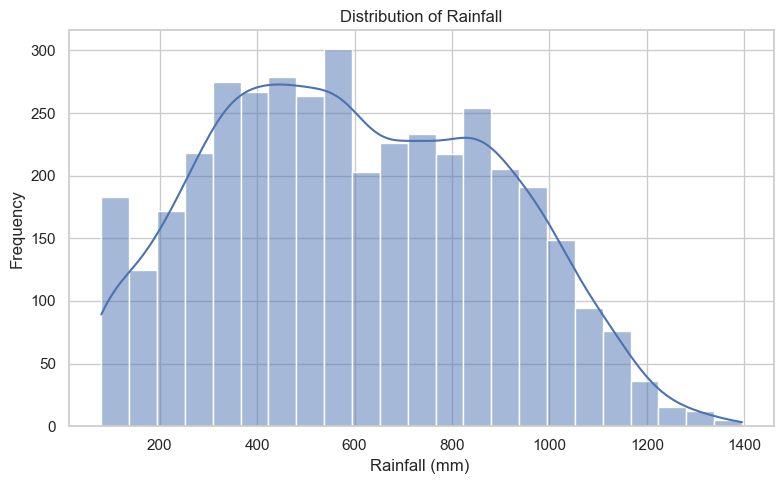

In [196]:
#Univariate: Rainfall distribution
plt. figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall") 
plt.xlabel("Rainfall (mm) ")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

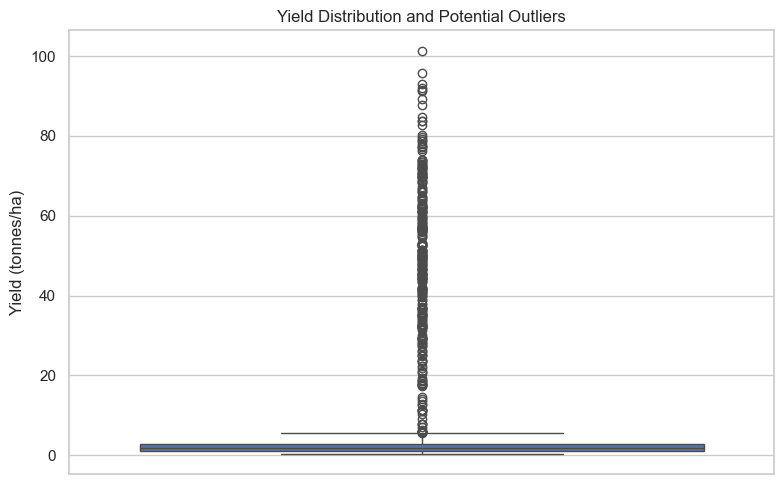

In [197]:
#Univariate: Boxplot for yield
plt. figure(figsize=(8, 5))
sns. boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 9. Outlier Analysıs
Investigate potential outliers using statistical and visual methods.

# Univariate: Season distribution (Pie Chart)

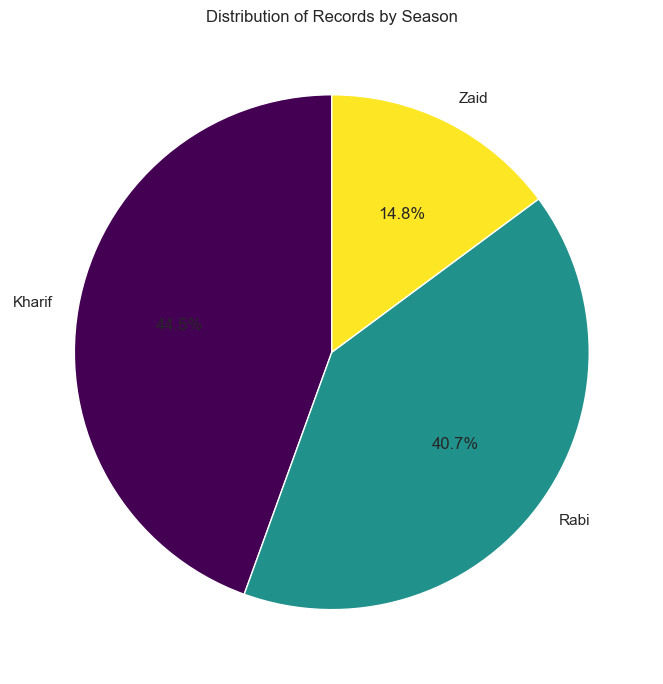

In [198]:
plt.figure(figsize= (7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default Season" label on the y-axis 
plt.tight_layout()
plt.show()

In [199]:
# IQR-based outlier summary for numerical columns
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary. append({
        "Column": col,
    "Lower_Bound": lower,
    "Upper_Bound": upper,
    "Outlier_Count": count,
    "Outlier_Percentage": round(count / len(df) * 100, 2)
})
outlier_summary = pd.DataFrame (outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)
outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


## 10.Bivariate Analysis
Bivariate analysis examines relationships or differences between two variables.

Students should investigate relationships that are relevant to the seasonal agriculture problem.

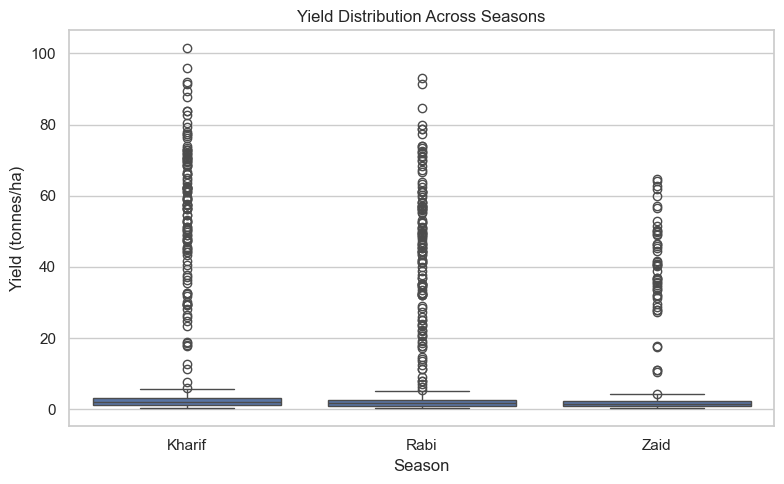

In [200]:
#Bivariate: Season vs Yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout ()
plt.show()

### Bar Plot For Bivariate Analysis

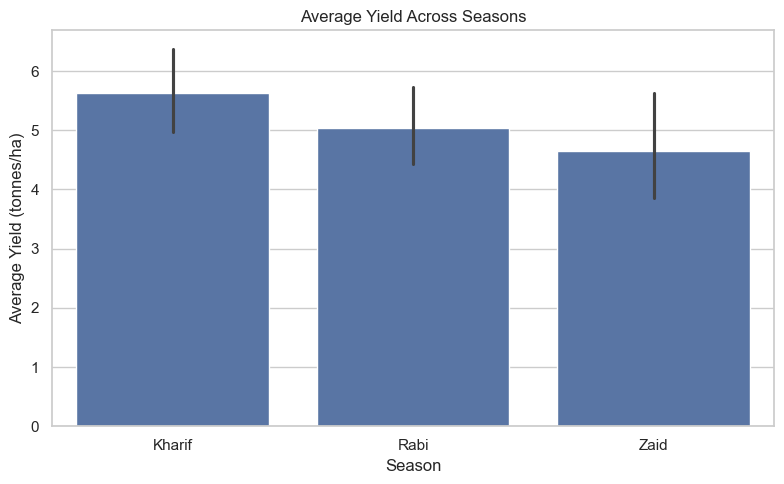

In [201]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

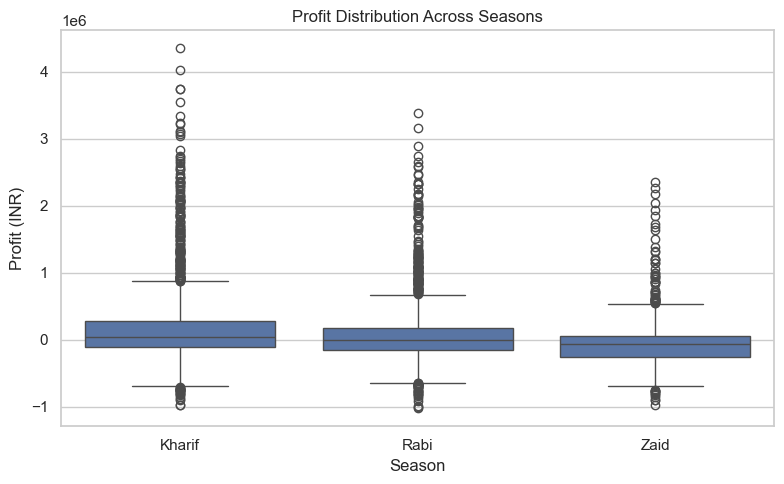

In [202]:
#Bivariate: Season vs Profit
plt. figure(figsize=(8,5))
sns. boxplot (data=df, x="Season", y="Profit_INR")
plt. title( "Profit Distribution Across Seasons") 
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt. show()

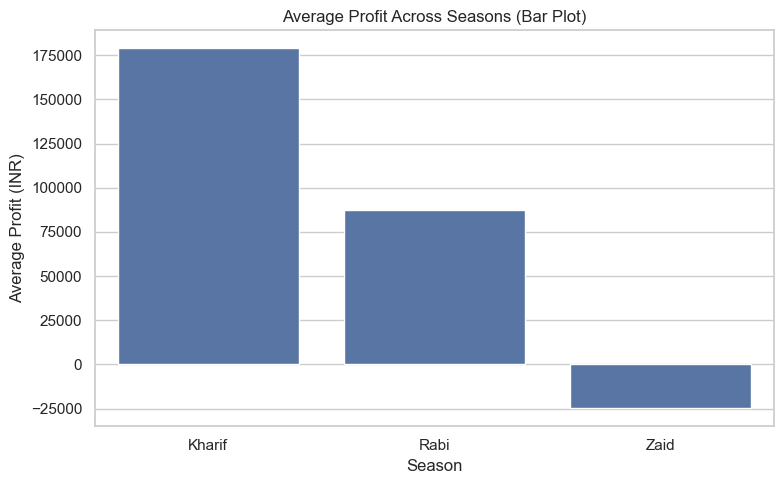

In [203]:
plt.figure(figsize=(8, 5))
sns.barplot (data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel ("Season")
plt.ylabel("Average Profit (INR)")
plt. tight_layout()
plt.show()

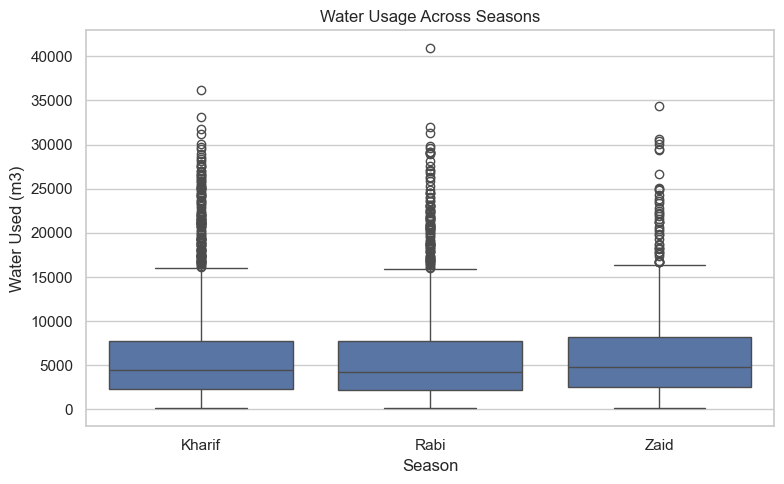

In [204]:
#Bivariate: Season vs Water Usage
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m3)")
plt.tight_layout()
plt.show()

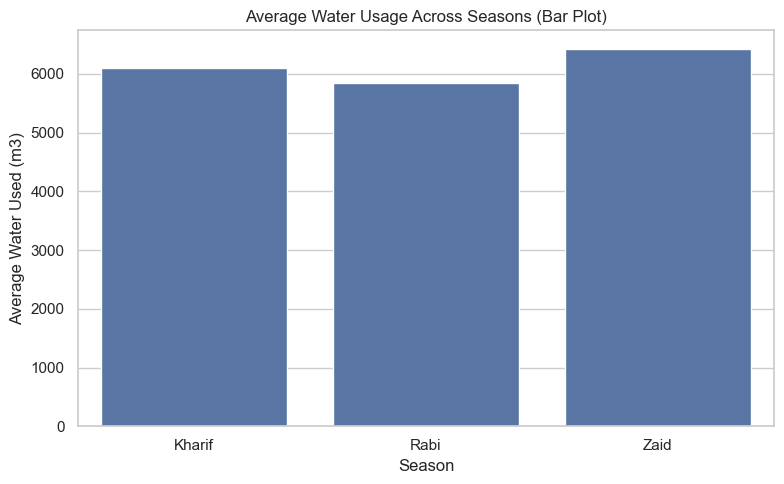

In [205]:
plt.figure(figsize= (8, 5)) 
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None) 
plt.title("Average Water Usage Across Seasons (Bar Plot)") 
plt.xlabel("Season")
plt.ylabel("Average Water Used (m3)")
plt.tight_layout()
plt.show()

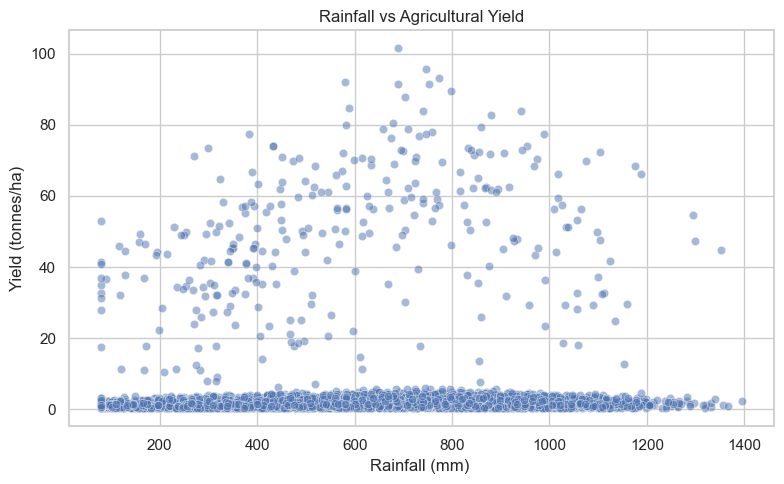

In [207]:
# Bivariate: Rainfall vs Yield
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha" , alpha=0.5)
plt.title("Rainfall vs Agricultural Yield") 
plt.xlabel ("Rainfall (mm) ")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

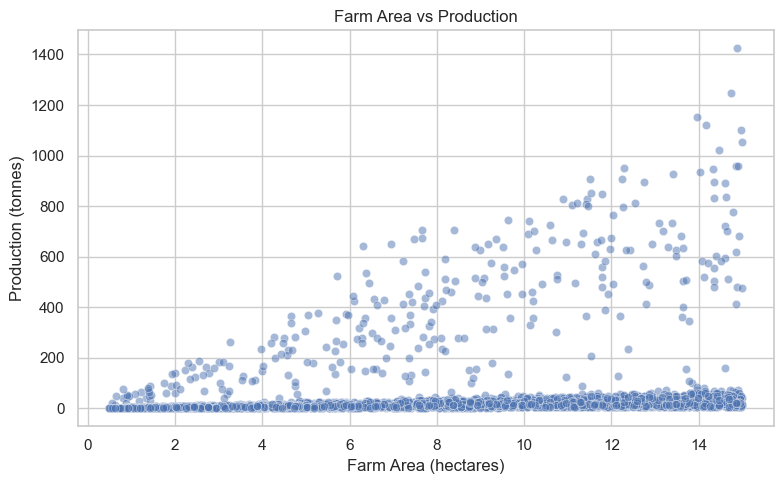

In [208]:
# Bivariate: Farm area vs Production
plt.figure(figsize= (8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)") 
plt.ylabel ("Production (tonnes)")
plt.tight_layout()
plt.show()

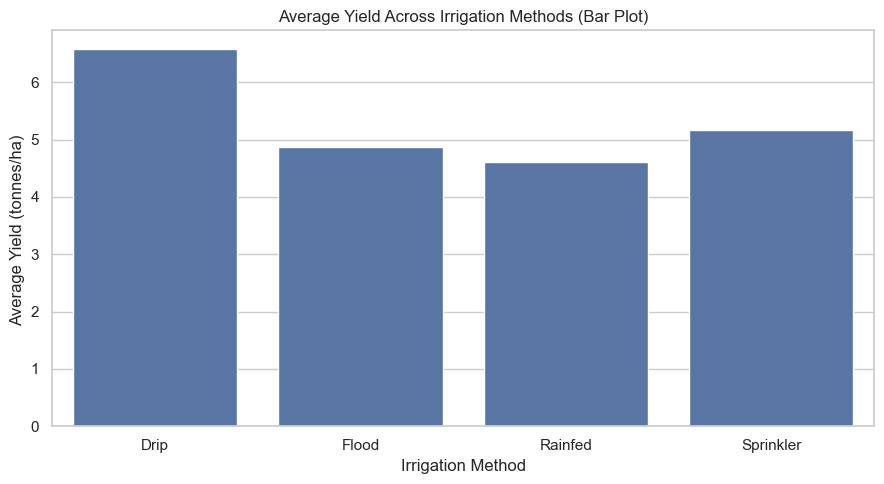

In [209]:
plt.figure (figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)") 
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha) ")
plt.tight_layout ()
plt.show()

## 11. Multivariate Analysis
Multivariate analysis examines more than two variables together.

Use multivariate plots to investigate how season interacts with other dimensions such as crop, region, environmental conditions, resource usage or economic performance.


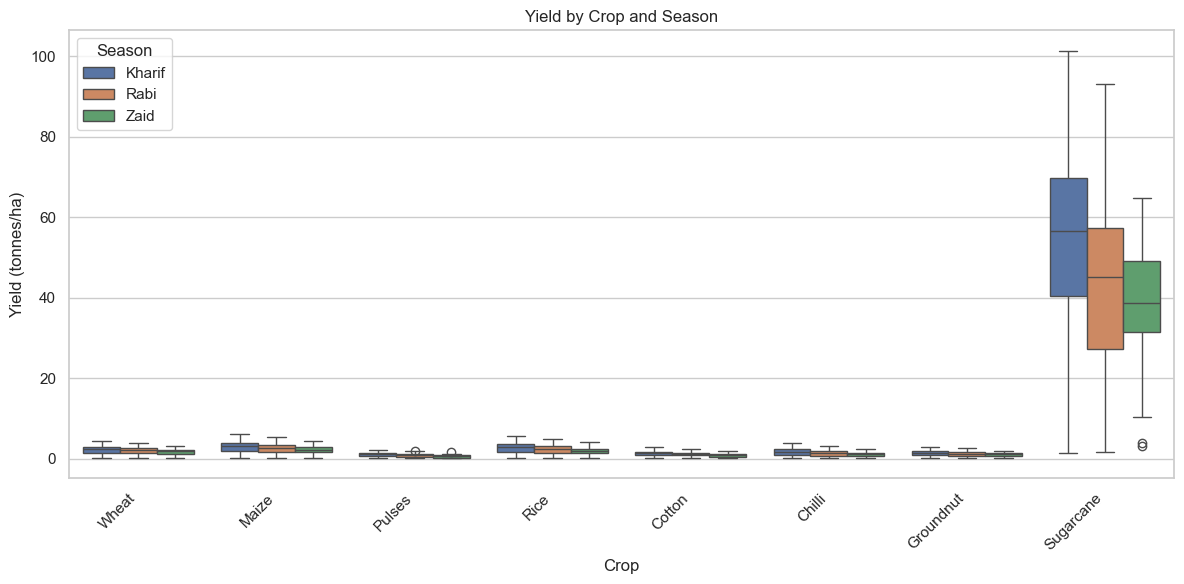

In [210]:
# Multivariate: Season, crop and yield
plt.figure(figsize=(12, 6))
sns. boxplot (data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season") 
plt.xlabel ("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

#### Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

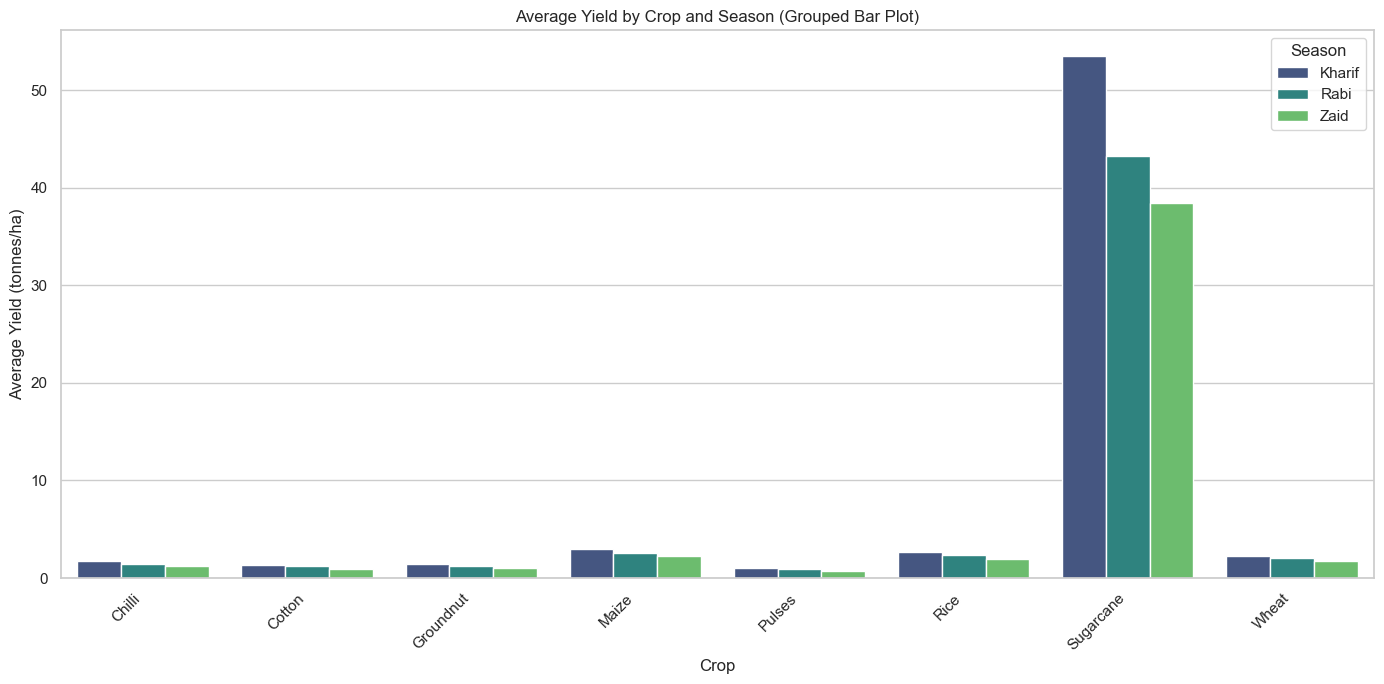

In [211]:
crop_season_summary = df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"].mean().reset_index()
crop_season_summary.columns = ["Crop", "Season", "Average_Yield"]

plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_summary, x="Crop", y="Average_Yield", hue="Season", palette="viridis")

plt.title("Average Yield by Crop and Season (Grouped Bar Plot)")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

#### Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

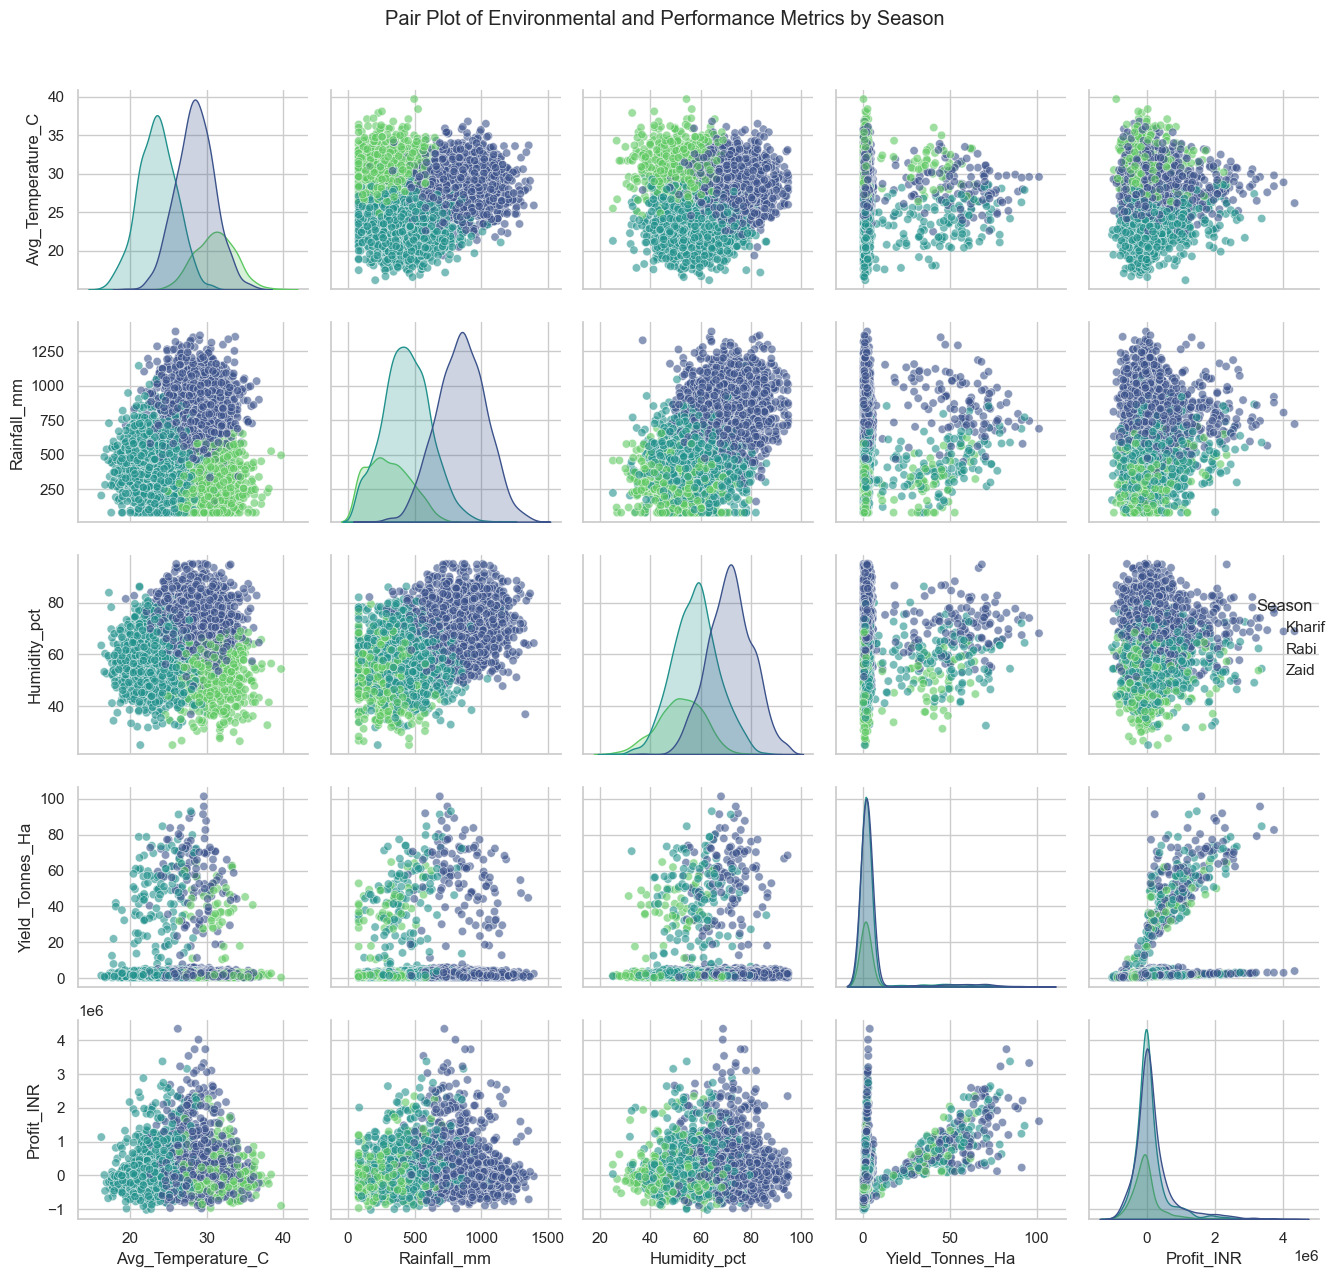

In [212]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot( df[selected_columns], hue='Season',palette='viridis',plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)
plt.tight_layout()
plt.show()

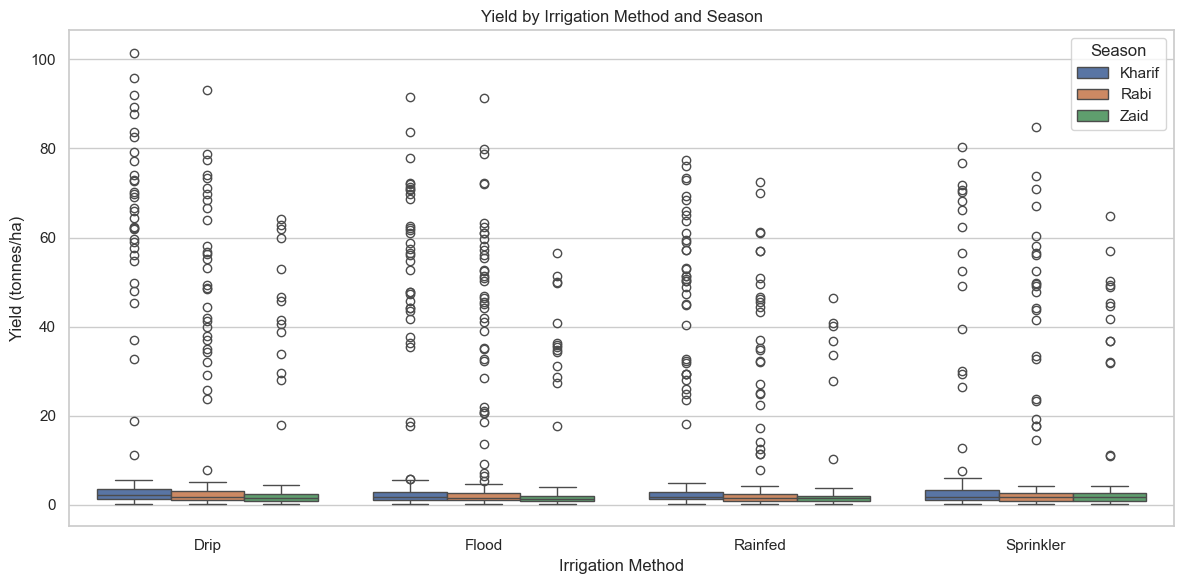

In [213]:
#Multivariate: Season, irrigation and yield
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout ()
plt.show()

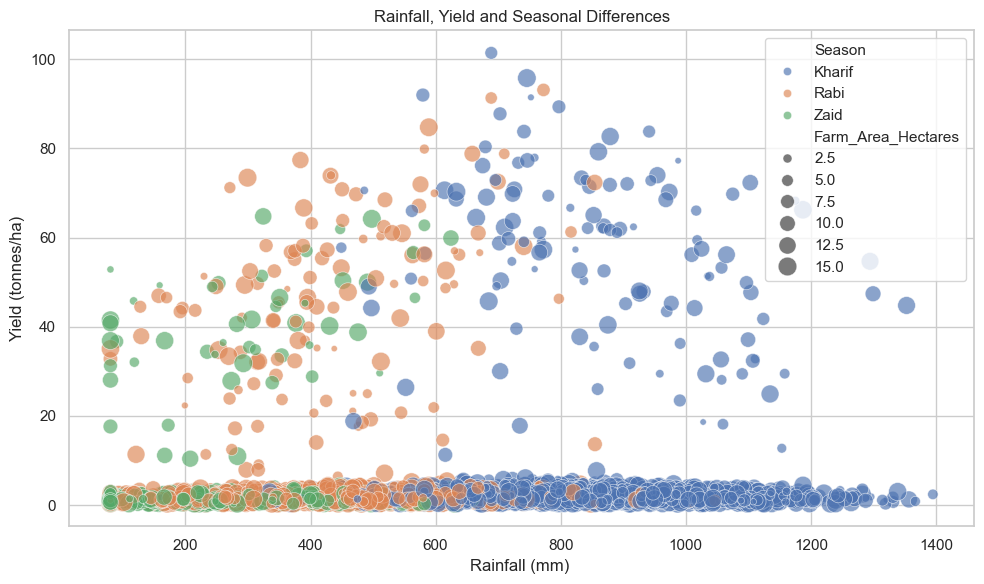

In [214]:
#Multivariate: Rainfall, yield and season
plt. figure(figsize= (10, 6))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",hue="Season",size="Farm_Area_Hectares" ,sizes=(20, 180), alpha=0.65)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel ("Rainfall (mm) ")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

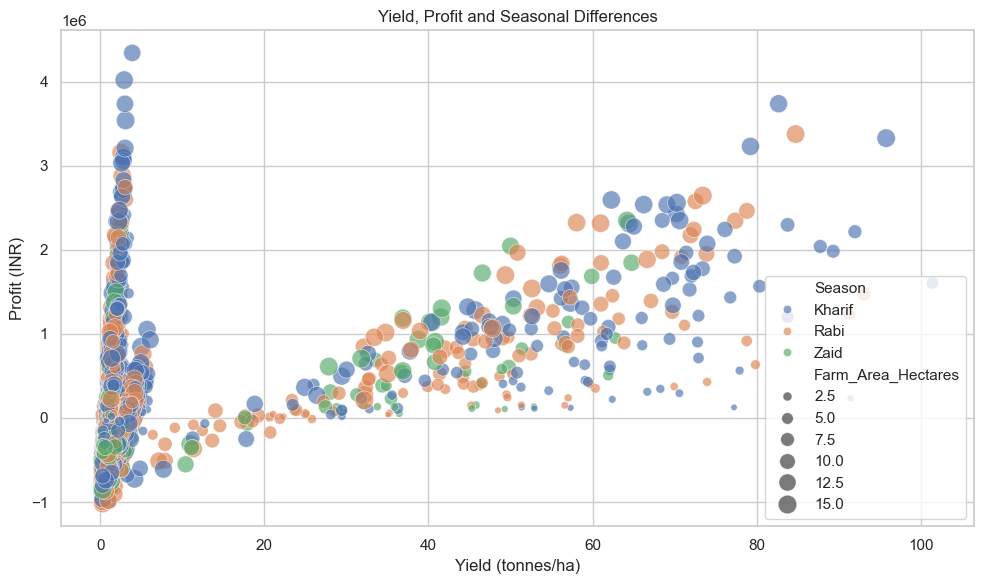

In [215]:
#Multivariate: Profit, yield and season
plt.figure (figsize= (10, 6))
sns.scatterplot(data=df,x="Yield_Tonnes_Ha",y="Profit_INR",hue="Season", size="Farm_Area_Hectares",sizes=(20, 180), alpha=0.65)
plt.title("Yield, Profit and Seasonal Differences") 
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

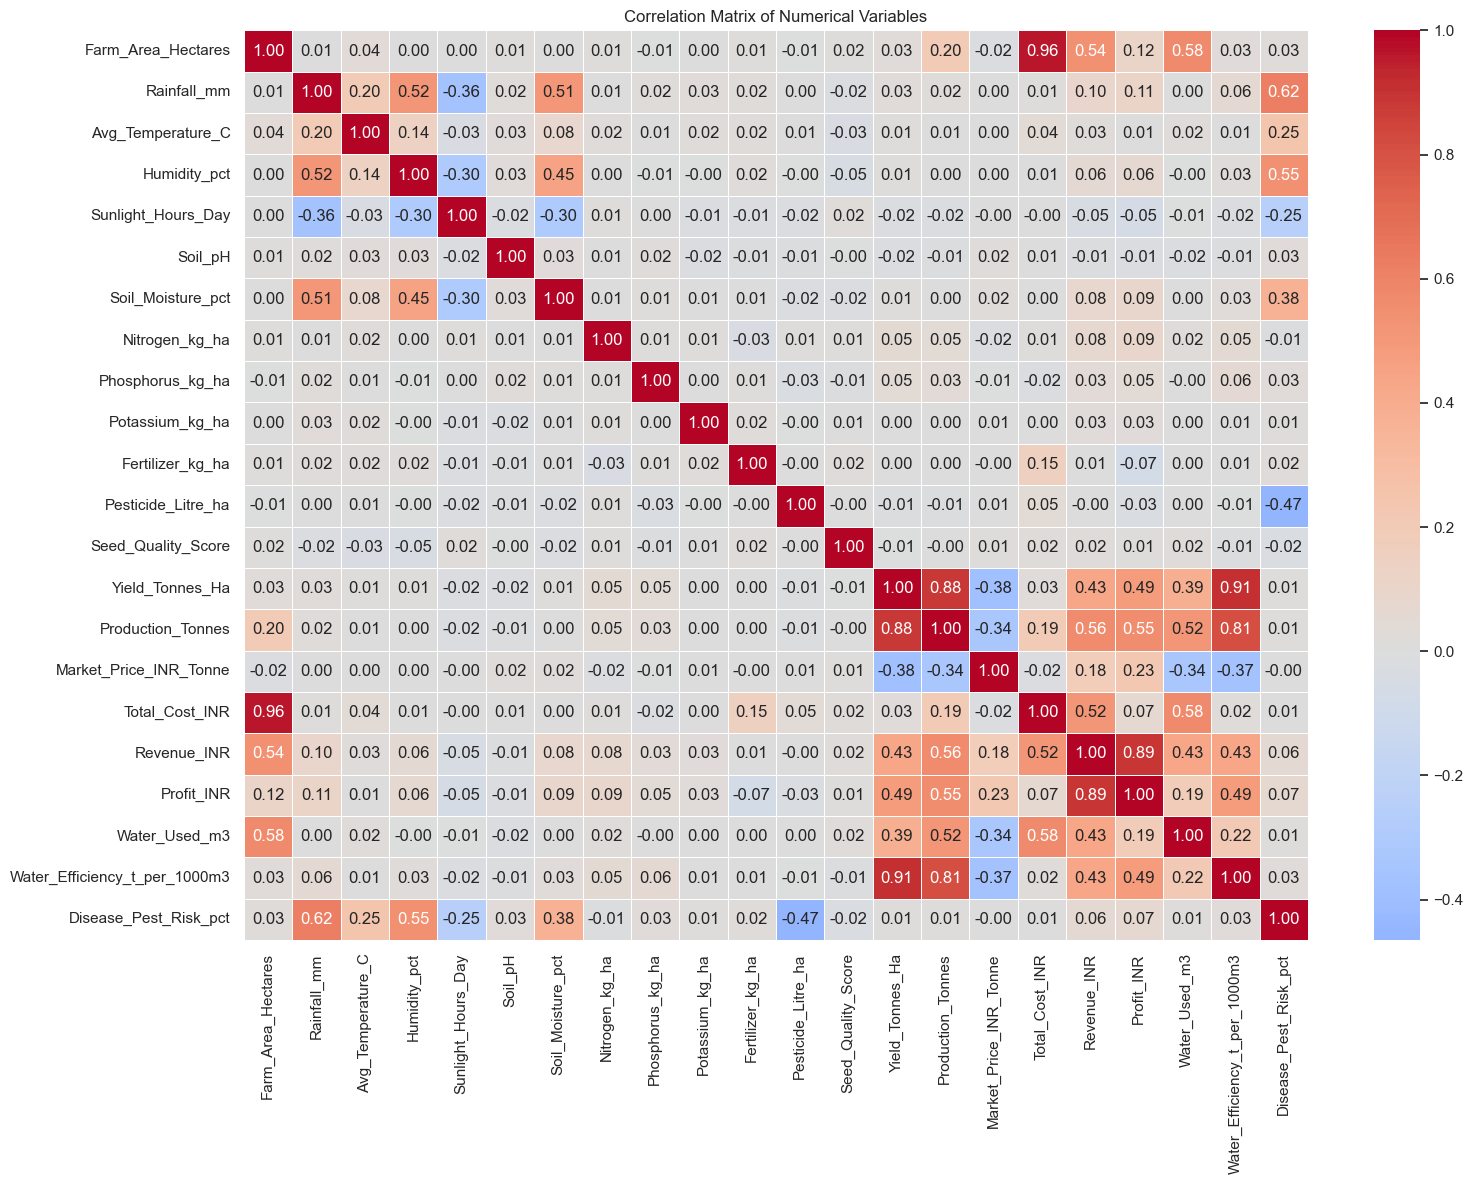

In [216]:
#Correlation heatmap for numerical variables
plt. figure(figsize= (16, 12))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f",
    cmap="coolwarm", 
    center=0, 
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 12.Seasonal Comparison

In [217]:
#General seasonal summary
season_metrics = df. groupby("Season"). agg(
    Records= ("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used= ("Water_Used_m3","mean")
).round(2)
season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [218]:
#Compare crop performance within each season
crop_season_summary =( 
    df.groupby (["Season", "Crop"])
      .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"), 
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
       )
       .round (2)
       .sort_values (["Season", "Average_Yield"], ascending=[True, False])
)
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

In [219]:
# Identify unusually high and low profit records by season

season_profit_stats = df.groupby("Season")["Profit_INR"].agg(
    ["mean", "median", "min", "max", "std"]
).round(2)

season_profit_stats

,mean,median,min,max,std
Season,,,,,
Kharif,"178,914.65","38,808.00",-976860,4345421,"611,549.78"
Rabi,"87,689.47","-3,187.00",-1019223,3378879,"489,901.25"
Zaid,"-24,804.82","-62,144.00",-965197,2349990,"436,356.75"


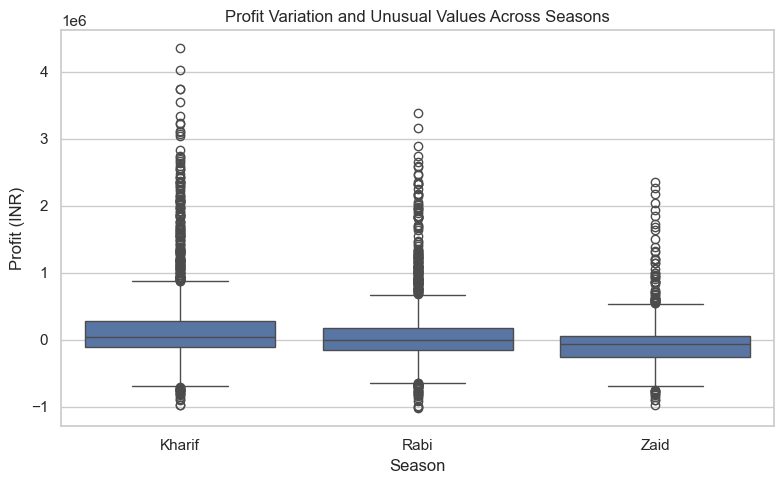

In [114]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Variation and Unusual Values Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

In [223]:
 # Student Analysis 1: Regional Differences
regional_summary = df.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

regional_summary = regional_summary.sort_values(
    "Average_Yield", ascending=False
)

regional_summary

,Average_Yield,Average_Profit,Total_Production,Average_Water_Efficiency
State,,,,
Punjab,6.12,"136,025.64","25,280.82",5.62
Karnataka,5.69,"119,422.34","23,341.30",5.56
Gujarat,5.66,"117,568.24","23,586.01",5.58
Telangana,5.04,"108,829.62","20,255.16",5.46
Maharashtra,5.02,"135,428.86","22,519.83",5.28
Madhya Pradesh,4.99,"86,840.76","18,667.08",5.27
Tamil Nadu,4.88,"117,744.75","19,807.58",5.31
Andhra Pradesh,4.63,"73,453.53","19,527.06",5.03


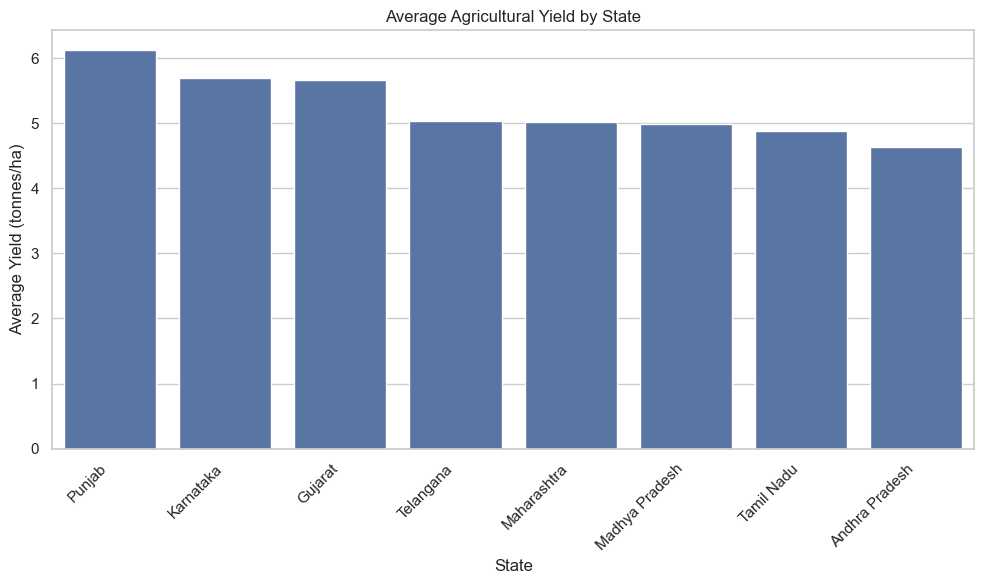

In [102]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=regional_summary.reset_index(),
    x="State",
    y="Average_Yield"
)

plt.title("Average Agricultural Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (tonnes/ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

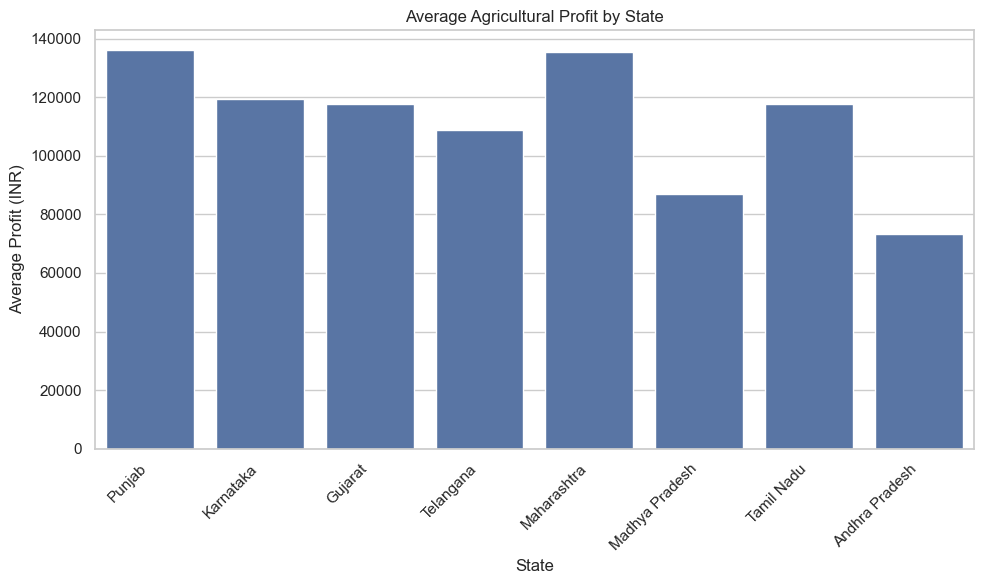

In [224]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=regional_summary.reset_index(),
    x="State",
    y="Average_Profit"
)

plt.title("Average Agricultural Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Student Analysis 1: Regional Differences
### Question
How does agricultural performance differ across different states?
### Why is this analysis relevant?
Agricultural performance may vary between geographical regions because environmental conditions, farming practices, resource availability, and crop patterns can differ across states. Therefore, comparing states can help identify regional differences in agricultural productivity and economic performance.
### Analysis
The average yield, average profit, and total production were compared across different states.
### Visualization
Bar plots are used to compare average yield and average profit across states.
### Interpretation
The analysis helps identify states with relatively higher or lower agricultural performance. These differences provide useful evidence for understanding regional variation in agricultural outcomes.
The analysis does not establish that location alone causes the observed differences because other factors such as crop type, rainfall, irrigation, and resource usage may also influence performance.


In [225]:
# Student Analysis 2: Disease and Pest Risk

season_risk = df.groupby("Season").agg(
    Average_Risk=("Disease_Pest_Risk_pct", "mean"),
    Median_Risk=("Disease_Pest_Risk_pct", "median"),
    Maximum_Risk=("Disease_Pest_Risk_pct", "max")
).round(2)

season_risk

,Average_Risk,Median_Risk,Maximum_Risk
Season,,,
Kharif,54.47,54.50,88.90
Rabi,40.48,40.60,71.20
Zaid,38.22,37.90,71.60


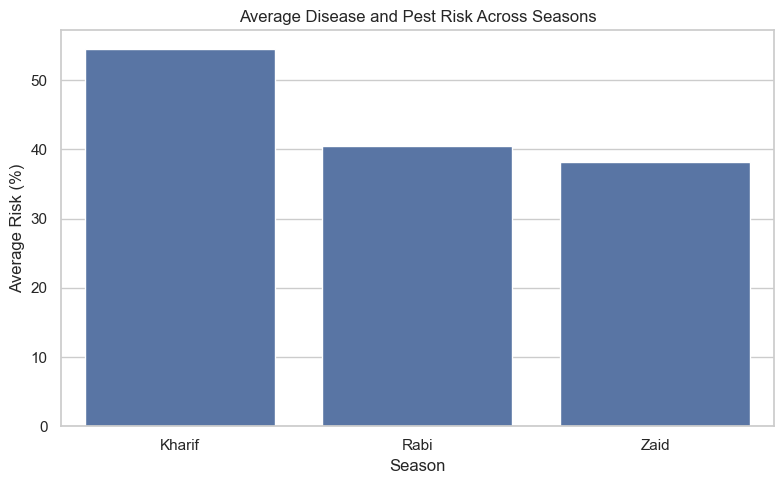

In [226]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_risk.reset_index(),
    x="Season",
    y="Average_Risk"
)

plt.title("Average Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Risk (%)")
plt.tight_layout()
plt.show()

In [227]:
state_risk = df.groupby("State").agg(
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2).sort_values(
    "Average_Risk", ascending=False
)

state_risk

,Average_Risk
State,
Madhya Pradesh,47.08
Andhra Pradesh,46.72
Maharashtra,46.44
Telangana,46.36
Tamil Nadu,46.28
Karnataka,46.06
Punjab,46.00
Gujarat,45.95


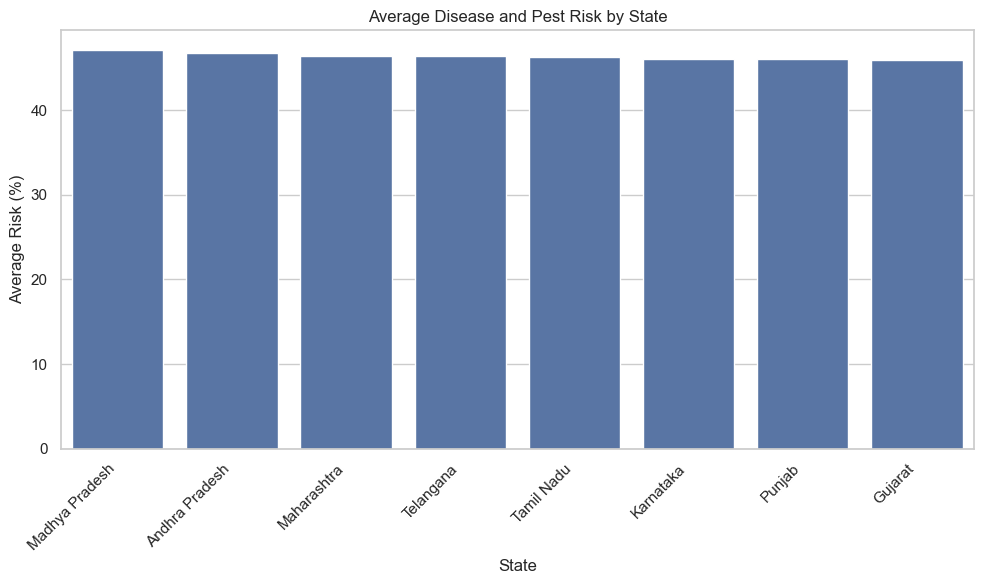

In [228]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_risk.reset_index(),
    x="State",
    y="Average_Risk"
)

plt.title("Average Disease and Pest Risk by State")
plt.xlabel("State")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Student Analysis 2: Disease and Pest Risk Patterns
### Question
How does disease and pest risk vary across different seasons and regions?
### Why is this analysis relevant?
Disease and pest risk is an important agricultural condition that can affect farming performance. Examining its variation across seasons and regions can help identify periods or areas where higher levels of risk are observed.
### Analysis
The average disease and pest risk percentage was calculated for each season and state.
### Visualization
Bar plots are used to compare average disease and pest risk across seasons and states.
### Interpretation
The analysis identifies seasons and regions with relatively higher observed disease and pest risk. These observations can help highlight areas that may require further investigation.
However, the analysis does not prove that disease and pest risk directly caused changes in yield or profit. Other environmental, resource, crop, and economic factors may also contribute to agricultural performance.


In [108]:
# Student Analysis 3: Economic Performance

economic_summary = df.groupby("Season").agg(
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

economic_summary

,Average_Revenue,Average_Cost,Average_Profit
Season,,,
Kharif,"710,719.06","531,804.41","178,914.65"
Rabi,"601,526.05","513,836.58","87,689.47"
Zaid,"519,171.90","543,976.73","-24,804.82"


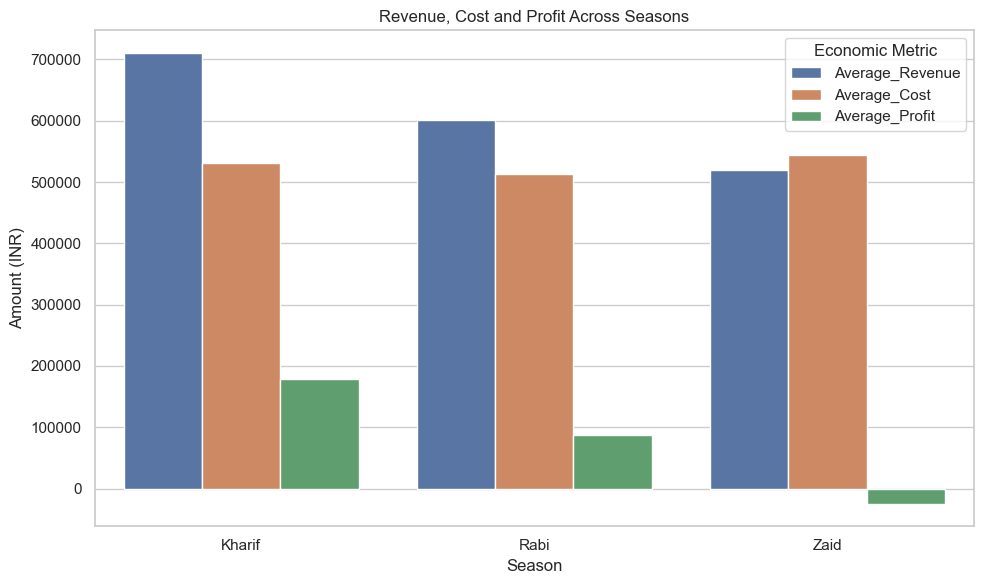

In [109]:
economic_plot = economic_summary.reset_index().melt(
    id_vars="Season",
    var_name="Economic_Metric",
    value_name="Amount"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=economic_plot,
    x="Season",
    y="Amount",
    hue="Economic_Metric"
)

plt.title("Revenue, Cost and Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.legend(title="Economic Metric")
plt.tight_layout()
plt.show()

## Student Analysis 3: Economic Performance
### Question
How does economic performance vary across agricultural seasons in terms of revenue, cost, and profit?
### Why is this analysis relevant?
Agricultural performance is not determined only by production and yield. Economic outcomes are also important for evaluating the overall performance of farming activities. Comparing revenue, total cost, and profit across seasons provides a broader understanding of seasonal economic differences.
### Analysis
Average revenue, average total cost, and average profit were calculated for each season.
### Visualization
A grouped bar chart is used to compare revenue, cost, and profit across seasons.
### Interpretation
The results show differences in economic performance between seasons. A season with high revenue does not necessarily generate high profit because production costs can also be higher.
The findings should therefore be interpreted using both revenue and cost rather than revenue alone.


# Key Insights from the Analysis

## Insight 1: Kharif has the highest average agricultural yield

**1. Observation:**
Kharif season shows the highest average agricultural yield compared with Rabi and Zaid seasons.

**2. Evidence:**
The seasonal yield comparison using box plots and bar plots shows that average yield varies across the three seasons, with Kharif showing the strongest average performance.

**3. Interpretation:**
This indicates that agricultural productivity differs across seasons, and Kharif records relatively higher yield in the available dataset.

**4. Limitation:**
This finding does not mean that the Kharif season itself causes higher yield. Other factors such as crop type, rainfall, irrigation, soil conditions, and farming practices may also contribute to the observed difference.

## Insight 2: Kharif has the highest disease and pest risk

**1. Observation:**
Disease and pest risk is considerably higher during Kharif compared with Rabi and Zaid.

**2. Evidence:**
The seasonal disease and pest risk analysis shows average risk values of approximately 54.47% for Kharif, 40.48% for Rabi, and 38.22% for Zaid.

**3. Interpretation:**
The dataset indicates that Kharif has the highest observed level of disease and pest risk and may therefore be a season requiring greater attention to risk monitoring.

**4. Limitation:**
The analysis only shows a seasonal difference in reported risk. It does not establish that the season itself causes higher disease or pest risk.

## Insight 3: Kharif has the strongest average economic performance

**1. Observation:**
Kharif has the highest average profit among the three seasons.

**2. Evidence:**
The economic analysis shows average profit of approximately ₹178,915 for Kharif, compared with ₹87,689 for Rabi and approximately −₹24,805 for Zaid.

**3. Interpretation:**
Kharif records the strongest average economic performance in terms of profit within this dataset.

**4. Limitation:**
Higher profit cannot be attributed to the season alone because revenue, production, market price, crop selection, and costs may all influence profit.

## Insight 4: Zaid shows negative average profit

**1. Observation:**
Zaid is the only season with a negative average profit.

**2. Evidence:**
The economic summary shows average revenue of approximately ₹519,172 and average cost of approximately ₹543,977 for Zaid, resulting in an average profit of approximately −₹24,805.

**3. Interpretation:**
The available records indicate that average costs are higher than average revenue during Zaid, resulting in negative average profitability.

**4. Limitation:**
This does not mean that every Zaid farming activity is unprofitable. The value represents an average across the available records, and individual farms or crops may have different outcomes.

## Insight 5: Agricultural performance differs across states

**1. Observation:**
Average agricultural yield varies across different states.

**2. Evidence:**
The regional analysis shows substantial differences in average yield, with Punjab recording the highest average yield at approximately 6.12 tonnes/ha in the dataset.

**3. Interpretation:**
The results indicate that agricultural performance is not uniform across geographical regions.

**4. Limitation:**
The difference between states cannot be interpreted as being caused by geographical location alone. Crop composition, environmental conditions, irrigation, soil characteristics, and resource usage may differ between states.

## Insight 6: Farm area is positively associated with total production

**1. Observation:**
The Farm Area versus Production scatter plot shows an overall positive relationship between farm area and total production.

**2. Evidence:**
The scatter plot of `Farm_Area_Hectares` against `Production_Tonnes` shows that larger farm areas generally tend to be associated with higher production values.

**3. Interpretation:**
The dataset suggests that farm size and total production have a positive association.

**4. Limitation:**
A larger farm area does not necessarily guarantee higher productivity per hectare. The analysis concerns total production, which is naturally influenced by the amount of land available, and does not establish causation.

## Insight 7: Yield varies across irrigation methods

**1. Observation:**
Average agricultural yield differs between irrigation methods.

**2. Evidence:**
The irrigation-method bar plot and the irrigation-method-by-season box plot show differences in yield distributions among irrigation methods.

**3. Interpretation:**
The results indicate that irrigation method is associated with differences in observed agricultural yield, and these differences may also vary across seasons.

**4. Limitation:**
The analysis does not prove that a particular irrigation method causes higher yield. Other variables such as rainfall, crop type, soil moisture, and farm conditions may influence the observed relationship.

## Insight 8: Rainfall and yield show a measurable relationship

**1. Observation:**
The rainfall-versus-yield scatter plot shows variation in yield at different rainfall levels.

**2. Evidence:**
The scatter plot of `Rainfall_mm` and `Yield_Tonnes_Ha`, including seasonal differences, shows that yield does not remain constant as rainfall changes.

**3. Interpretation:**
This indicates that rainfall and agricultural yield have an observable relationship in the dataset, although the strength and direction of the relationship may differ across observations and seasons.

**4. Limitation:**
The relationship between rainfall and yield should not be interpreted as a direct causal relationship. Yield can also depend on temperature, soil conditions, irrigation, crop type, fertilizer usage, and other factors.

## Overall Insight

The analysis demonstrates that agricultural performance varies across **seasons, regions, crops, environmental conditions, resource-use patterns, and economic conditions**. Kharif shows relatively strong yield and profit performance but also has the highest observed disease and pest risk. Zaid shows comparatively weaker economic performance, including negative average profit. Regional and irrigation-related differences further indicate that agricultural outcomes are influenced by multiple interacting factors.

These findings provide useful evidence for seasonal agricultural planning, but they should be interpreted as **patterns and associations within the dataset rather than proof of cause-and-effect relationships**.


# Recommendations

Based on the analysis performed on the dataset, the following evidence-based recommendations can be made:

### 1. Give greater attention to Kharif-season risk management

Kharif shows the highest average disease and pest risk at approximately 54.47%, compared with 40.48% for Rabi and 38.22% for Zaid. Therefore, disease and pest monitoring during the Kharif season may require greater attention.

### 2. Investigate the factors behind strong Kharif economic performance

Kharif has the highest average revenue of approximately ₹710,719 and the highest average profit of approximately ₹178,915 per record. Further analysis of the crop, environmental and resource conditions associated with this performance could help identify useful seasonal patterns.

### 3. Examine the economic challenges observed in Zaid

Zaid has an average revenue of approximately ₹519,172 and an average cost of approximately ₹543,977, resulting in an average loss of approximately ₹24,805. This indicates that the relationship between revenue and cost during Zaid requires further investigation.

### 4. Consider regional differences when interpreting agricultural performance

The analysis shows substantial differences between states. Punjab has the highest average yield in the dataset at approximately 6.12 tonnes/ha, while other states show lower average yields. Regional conditions should therefore be considered when comparing agricultural performance.

### 5. Use resource-efficiency measures along with production measures

Agricultural performance should not be evaluated using yield or profit alone. Water usage and water-efficiency measures can provide additional information about how efficiently agricultural resources are being used across seasons.

### 6. Limitations of the recommendations

These recommendations are based only on patterns observed in the available dataset. The analysis identifies relationships and differences but does not establish causal relationships. Factors such as crop selection, weather conditions, irrigation methods, market prices, and farming practices may interact with each other. Therefore, further analysis would be required before applying these findings to real-world agricultural decision-making.


# Conclusion

The analysis shows that agricultural performance varies across seasons in terms of yield, resource usage, economic performance, environmental conditions, and disease and pest risk.

Kharif showed the highest average yield and profit, but also the highest disease and pest risk. Zaid showed weaker economic performance, with average costs exceeding average revenue.

Differences were also observed across states, crops, and irrigation methods. Relationships between rainfall, farm area, yield, and production were identified, but these do not prove causation.

Overall, the findings provide useful evidence for understanding seasonal agricultural patterns and supporting better seasonal planning, while recognizing the limitations of the available dataset.
